<a href="https://colab.research.google.com/github/Bivasgithub/Sea_Breeze_Front/blob/main/SB_days_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Filtering of SB Days**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3
def compute_sbf_trend(file_path, year, month, day):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()

    # Convert numeric columns
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DATE
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)

    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15

    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE FUNCTION
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([
                values[i - 1],
                values[i],
                values[i + 1]
            ])

            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)
        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
    df["q_3point_slope"] = moving_slope(df["q_gkg"])
    df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
    df = df.dropna()

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0
    t1 = (df.loc[mask_u_positive, "q_3point_slope"].abs().idxmax())

    mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))
    t2 = (df.loc[mask_t2, "q_3point_slope"].idxmax())

    t3 = (df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax())

    # STORE FLAGS
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True

    return df


# FILES FOR 5 STATIONS
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# SELECT 7 CONSECUTIVE DAYS
dates = pd.date_range(start="2025-08-01", periods=31, freq="D")

# LOOP OVER DAYS
for current_date in dates:
    year = current_date.year
    month = current_date.month
    day = current_date.day

    # COMPUTE RESULTS
    results = {}
    for station, file in station_files.items():
        results[station] = compute_sbf_trend(file, year, month, day)

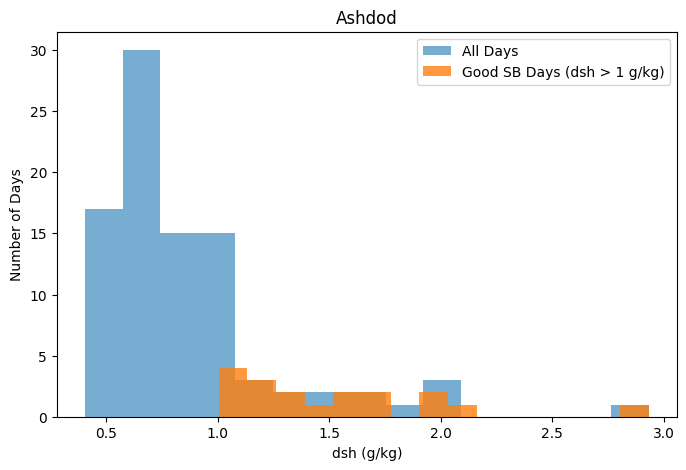

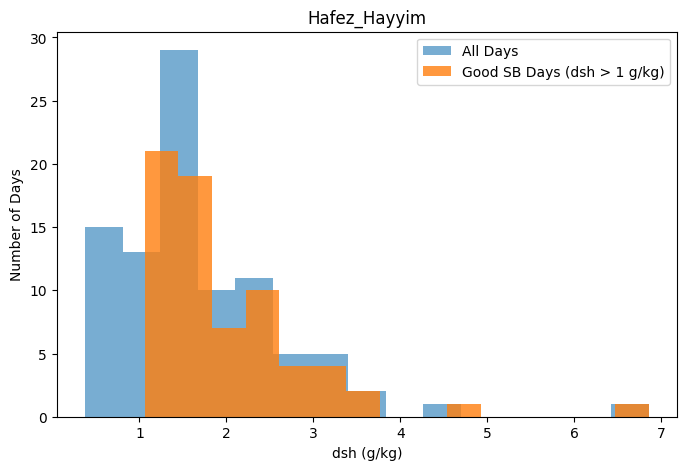

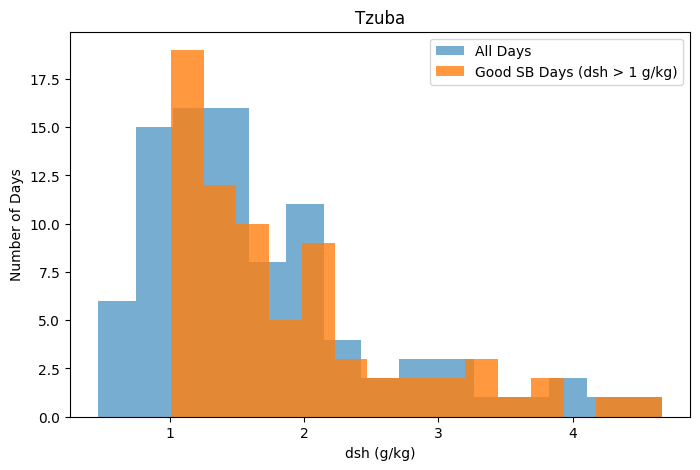

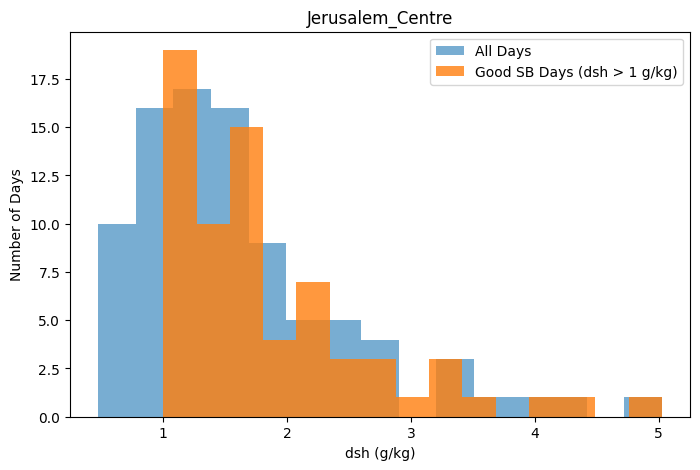

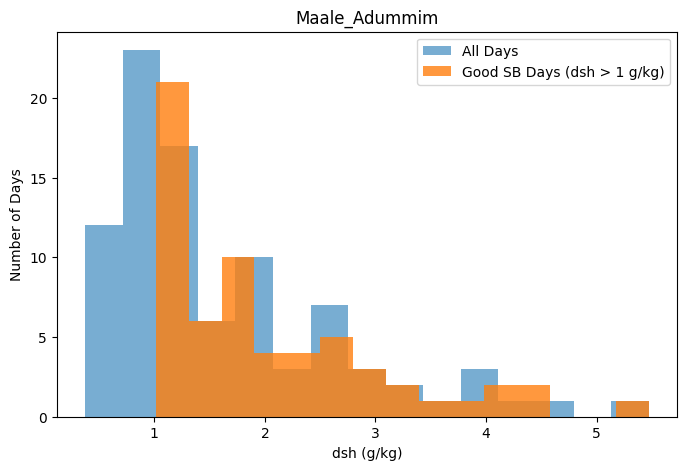

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3 AND dsh
def compute_sbf_trend(file_path, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )
    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:
        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # COMPUTE dsh
    dsh = np.nan
    try:
        n1 = df.index.get_loc(t1)
        if (n1 > 0) and (n1 < len(df)-1):
            dsh = (df["q_gkg"].iloc[n1+1] - df["q_gkg"].iloc[n1-1])
    except:
        pass

    # GOOD SB DAY?
    dsh_threshold = 1.0
    good_sb = False

    if not np.isnan(dsh):
        good_sb = dsh > dsh_threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "dsh": dsh, "good_sb": good_sb}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
dsh_all = {station: [] for station in station_files.keys()}

dsh_good = {
    station: []
    for station in station_files.keys()
}


# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(
            file,
            year,
            month,
            day
        )

        if result is None:
            continue

        dsh = result["dsh"]

        if np.isnan(dsh):
            continue

        dsh_all[station].append(dsh)

        if result["good_sb"]:
            dsh_good[station].append(dsh)


# HISTOGRAMS
for station in station_files.keys():

    plt.figure(figsize=(8,5))

    plt.hist(
        dsh_all[station],
        bins=15,
        alpha=0.6,
        label="All Days"
    )

    plt.hist(
        dsh_good[station],
        bins=15,
        alpha=0.8,
        label="Good SB Days (dsh > 1 g/kg)"
    )

    plt.xlabel("dsh (g/kg)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()

    plt.show()


# **Practice code for saving Good SB**

        Date           Station       dsh  Good_SB t1_time
0 2025-06-01            Ashdod  0.578704    False   05:10
1 2025-06-01      Hafez_Hayyim  1.755845     True   08:10
2 2025-06-01             Tzuba  2.478484     True   06:30
3 2025-06-01  Jerusalem_Centre  1.626157     True   07:50
4 2025-06-01     Maale_Adummim  0.565647    False   14:40


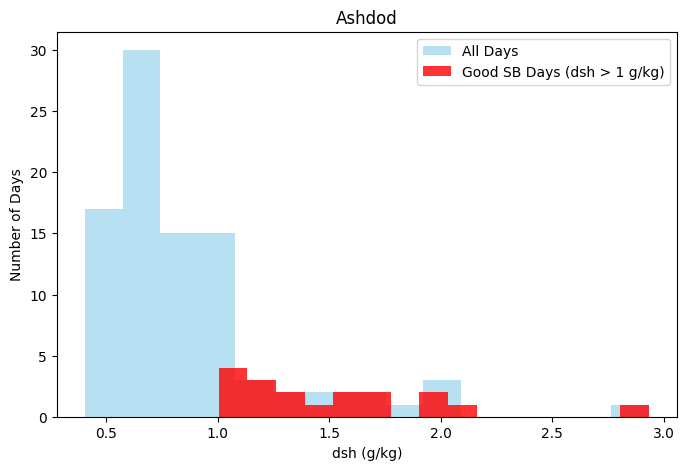

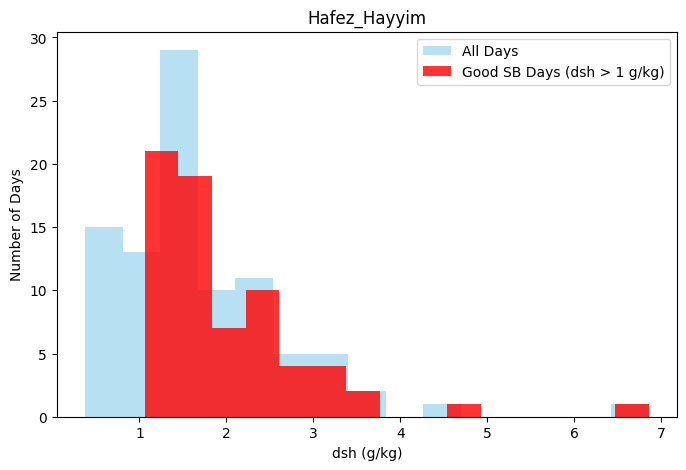

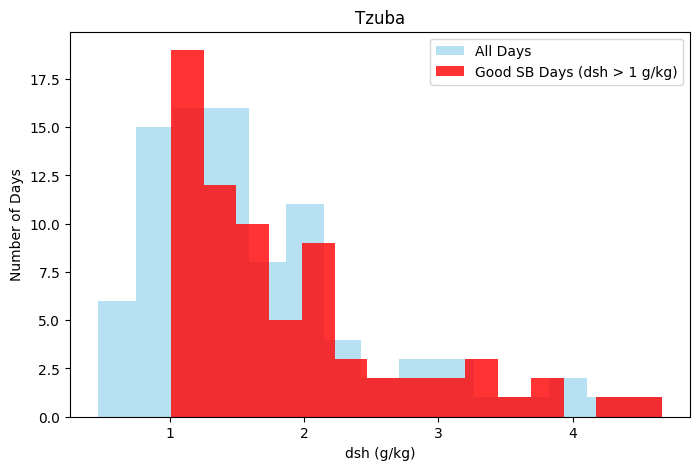

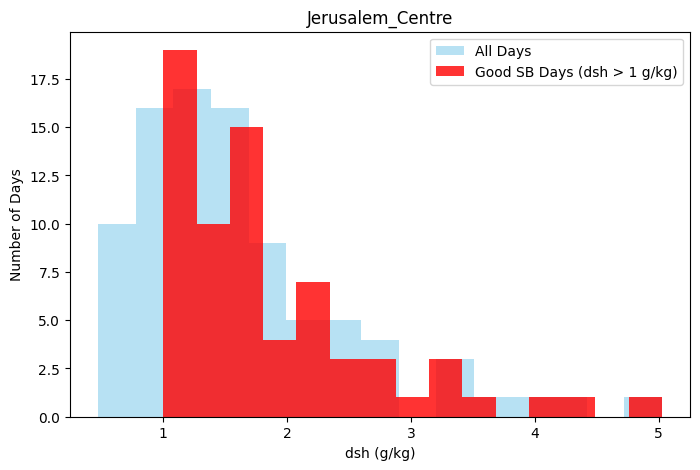

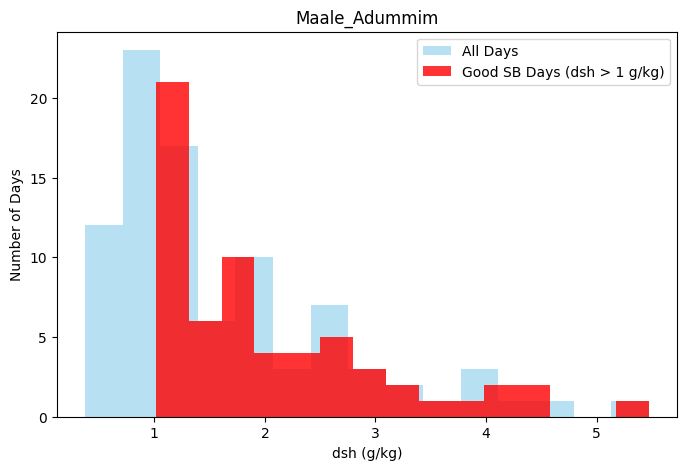

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3 AND dsh
def compute_sbf_trend(file_path, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:
        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # COMPUTE dsh
    dsh = np.nan
    try:
        n1 = df.index.get_loc(t1)
        if (n1 > 0) and (n1 < len(df)-1):
            dsh = (df["q_gkg"].iloc[n1+1] - df["q_gkg"].iloc[n1-1])
    except:
        pass

    # GOOD SB DAY?
    dsh_threshold = 1.0
    good_sb = False

    if not np.isnan(dsh):
        good_sb = dsh > dsh_threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "dsh": dsh, "good_sb": good_sb}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
dsh_all = {station: [] for station in station_files.keys()}

dsh_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []

# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(
            file,
            year,
            month,
            day
        )

        if result is None:
            continue

        dsh = result["dsh"]

        if np.isnan(dsh):
            continue

        # dsh_all[station].append(dsh)

        # if result["good_sb"]:
        #     dsh_good[station].append(dsh)
        dsh_all[station].append(dsh)

        if result["good_sb"]:
          dsh_good[station].append(dsh)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "dsh": dsh,
                              "Good_SB": result["good_sb"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})

# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_dsh_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="dsh")
pivot_df.to_excel("dsh_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    plt.hist(dsh_all[station], bins=15, alpha=0.6, label="All Days", color='skyblue')
    plt.hist(dsh_good[station], bins=15, alpha=0.8, label="Good SB Days (dsh > 1 g/kg)", color='red')

    plt.xlabel("dsh (g/kg)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()


In [ ]:
# STATISTICS
for station in station_files.keys():

    all_vals = np.array(dsh_all[station])

    print("\n")
    print("=" * 60)
    print(station)
    print("=" * 60)

    print("ALL DAYS")
    print("Count  :", len(all_vals))
    if len(all_vals) > 0:

        print("Mean   :", np.mean(all_vals))
        print("Median :", np.median(all_vals))
        print("Std    :", np.std(all_vals))
        print("Min    :", np.min(all_vals))
        print("Max    :", np.max(all_vals))

    good_vals = np.array(dsh_good[station])
    print("\nGOOD SB DAYS (dsh > 1 g/kg)")
    print("Count  :", len(good_vals))

    if len(good_vals) > 0:

        print("Mean   :", np.mean(good_vals))
        print("Median :", np.median(good_vals))
        print("Std    :", np.std(good_vals))
        print("Min    :", np.min(good_vals))
        print("Max    :", np.max(good_vals))



Ashdod
ALL DAYS
Count  : 91
Mean   : 0.8629037589970355
Median : 0.730356585025909
Std    : 0.4181685764336522
Min    : 0.4051934943912592
Max    : 2.932458682391063

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 18
Mean   : 1.522447806623383
Median : 1.4197985899173826
Std    : 0.4827668544129586
Min    : 1.004442727561191
Max    : 2.932458682391063


Hafez_Hayyim
ALL DAYS
Count  : 92
Mean   : 1.701115842880987
Median : 1.4749961270575813
Std    : 0.983666363956597
Min    : 0.3758810885490984
Max    : 6.854089298403823

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 69
Mean   : 2.020386895850439
Median : 1.682757880908408
Std    : 0.9351844264891317
Min    : 1.061473475162522
Max    : 6.854089298403823


Tzuba
ALL DAYS
Count  : 90
Mean   : 1.6684926795095767
Median : 1.3813199055768486
Std    : 0.8780548451430429
Min    : 0.46622100760791163
Max    : 4.66473755022104

GOOD SB DAYS (dsh > 1 g/kg)
Count  : 72
Mean   : 1.8868707735434316
Median : 1.610747461824754
Std    : 0.8489145473827322
Min    : 1.0

62


# **Onshone component should be +ve and noticebly increased**

        Date           Station       du1  Good_SB1 t1_time
0 2025-06-01            Ashdod  4.012998      True   05:10
1 2025-06-01      Hafez_Hayyim  2.049976      True   08:10
2 2025-06-01             Tzuba  2.157622      True   06:30
3 2025-06-01  Jerusalem_Centre  0.480936     False   07:50
4 2025-06-01     Maale_Adummim  0.116182     False   14:40


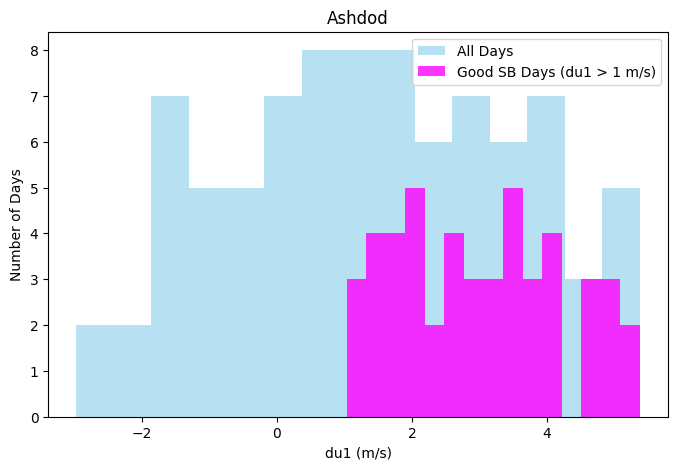

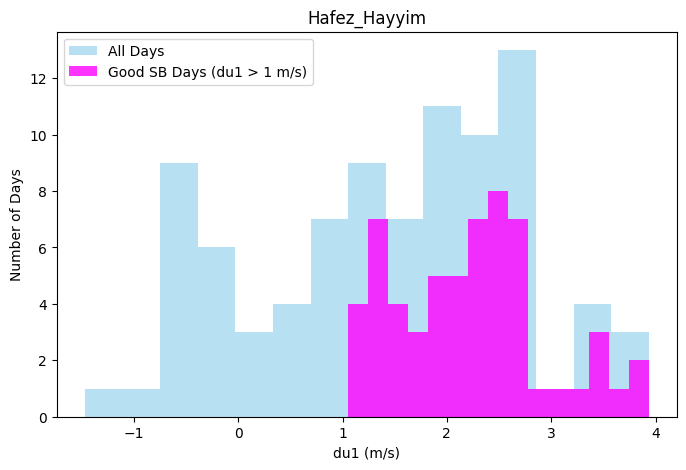

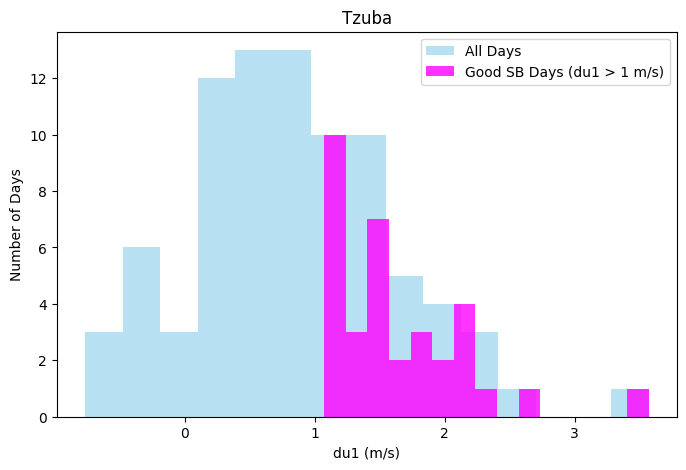

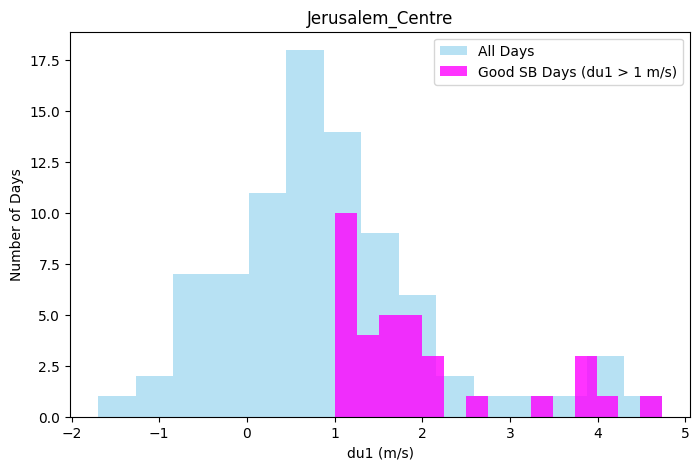

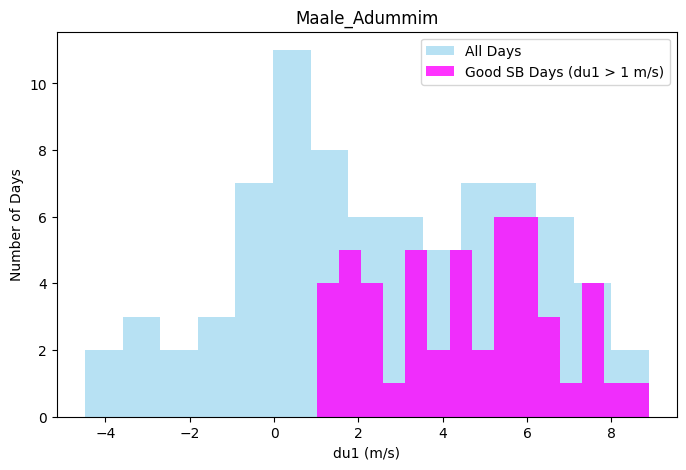

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3 AND dsh
def compute_sbf_trend(file_path, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:
        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # # COMPUTE dsh
    # dsh = np.nan
    # try:
    #     n1 = df.index.get_loc(t1)
    #     if (n1 > 0) and (n1 < len(df)-1):
    #         dsh = (df["q_gkg"].iloc[n1+1] - df["q_gkg"].iloc[n1-1])
    # except:
    #     pass

    du1 = np.nan
    try:
      n1 = df.index.get_loc(t1)
      if (n1 >= 6) and (n1 < len(df)-6):
        du1 = (df["V_onshore"].iloc[n1+6] - df["V_onshore"].iloc[n1-6])
    except:
      pass

    # GOOD SB DAY?
    du1_threshold = 1.0
    good_sb1 = False

    if not np.isnan(du1):
        good_sb1 = du1 > du1_threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "du1": du1, "good_sb1": good_sb1}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
du1_all = {station: [] for station in station_files.keys()}

du1_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []

# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, year, month, day)
        if result is None:
            continue

        du1 = result["du1"]

        if np.isnan(du1):
            continue

        # dsh_all[station].append(dsh)

        # if result["good_sb"]:
        #     dsh_good[station].append(dsh)
        du1_all[station].append(du1)

        if result["good_sb1"]:
          du1_good[station].append(du1)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "du1": du1,
                              "Good_SB1": result["good_sb1"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})

# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_du1_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="du1")
pivot_df.to_excel("du1_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    plt.hist(du1_all[station], bins=15, alpha=0.6, label="All Days", color='skyblue')
    plt.hist(du1_good[station], bins=15, alpha=0.8, label="Good SB Days (du1 > 1 m/s)", color='magenta')

    plt.xlabel("du1 (m/s)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()


In [ ]:
# STATISTICS
for station in station_files.keys():

    all_vals = np.array(du1_all[station])

    print("\n")
    print("=" * 60)
    print(station)
    print("=" * 60)

    print("ALL DAYS")
    print("Count  :", len(all_vals))
    if len(all_vals) > 0:

        print("Mean   :", np.mean(all_vals))
        print("Median :", np.median(all_vals))
        print("Std    :", np.std(all_vals))
        print("Min    :", np.min(all_vals))
        print("Max    :", np.max(all_vals))

    good_vals = np.array(du1_good[station])
    print("\nGOOD SB DAYS (du1 > 1 m/s)")
    print("Count  :", len(good_vals))

    if len(good_vals) > 0:

        print("Mean   :", np.mean(good_vals))
        print("Median :", np.median(good_vals))
        print("Std    :", np.std(good_vals))
        print("Min    :", np.min(good_vals))
        print("Max    :", np.max(good_vals))



Ashdod
ALL DAYS
Count  : 86
Mean   : 1.422544219053705
Median : 1.4352970417675084
Std    : 2.1099510188114095
Min    : -2.96473038611075
Max    : 5.37275497251735

GOOD SB DAYS (du1 > 1 m/s)
Count  : 48
Mean   : 2.9935949216510274
Median : 2.8884495889222093
Std    : 1.2257277357070742
Min    : 1.0322316475059283
Max    : 5.37275497251735


Hafez_Hayyim
ALL DAYS
Count  : 89
Mean   : 1.4620077939676461
Median : 1.5968811747453053
Std    : 1.2665451180380207
Min    : -1.466628532153476
Max    : 3.9342378463309258

GOOD SB DAYS (du1 > 1 m/s)
Count  : 59
Mean   : 2.2190972261172144
Median : 2.261914203194997
Std    : 0.7216177254184041
Min    : 1.0504451249070583
Max    : 3.9342378463309258


Tzuba
ALL DAYS
Count  : 84
Mean   : 0.8458541588560683
Median : 0.8113059213046486
Std    : 0.8010528434280838
Min    : -0.7666143901044631
Max    : 3.5696555826060496

GOOD SB DAYS (du1 > 1 m/s)
Count  : 34
Mean   : 1.6206813957023483
Median : 1.4940534251779591
Std    : 0.5286789393798584
Min    

# **practice**

        Date           Station       du1  Good_SB1 t1_time
0 2025-06-01            Ashdod -4.012998     False   05:10
1 2025-06-01      Hafez_Hayyim -2.049976     False   08:10
2 2025-06-01             Tzuba -2.157622     False   06:30
3 2025-06-01  Jerusalem_Centre -0.480936     False   07:50
4 2025-06-01     Maale_Adummim -0.116182     False   14:40


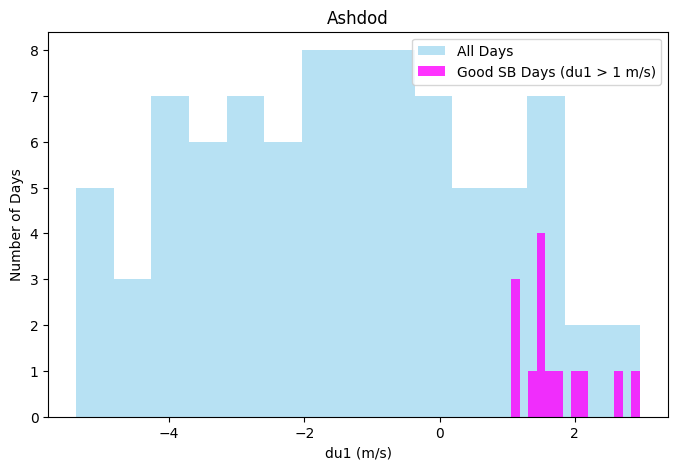

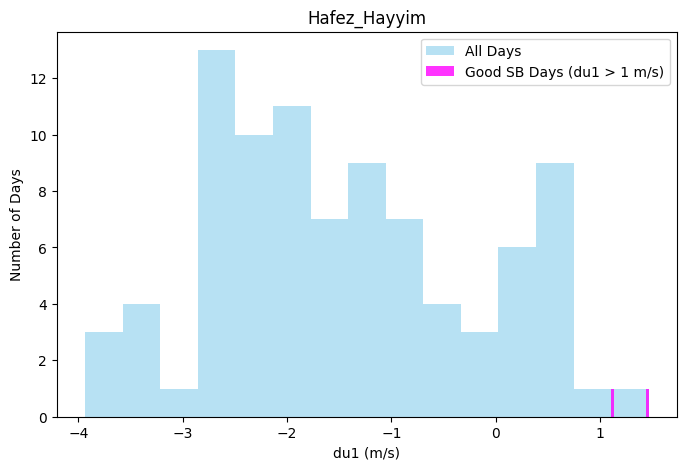

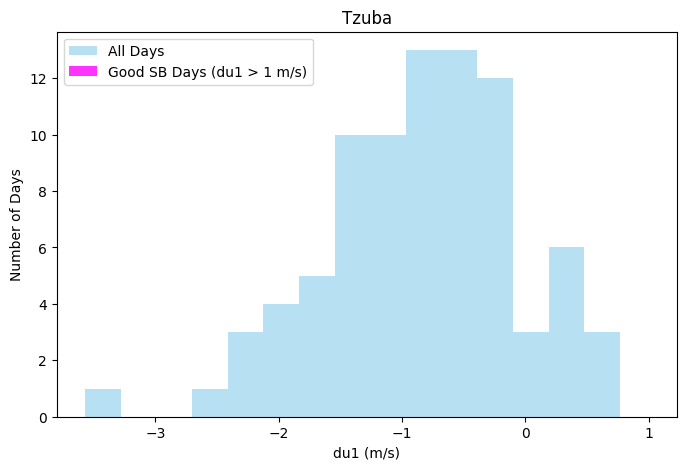

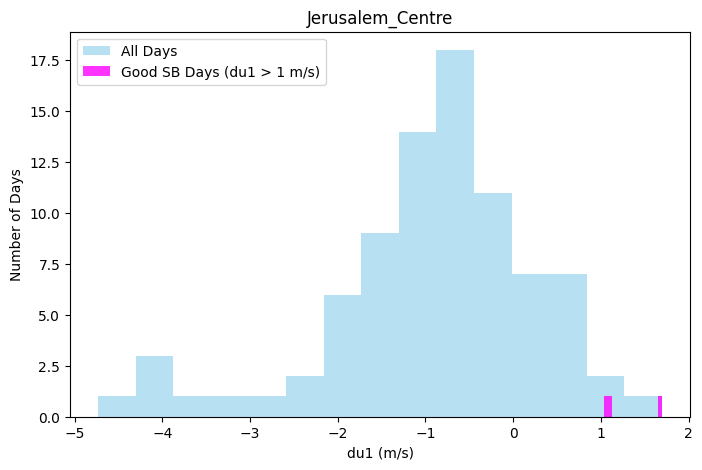

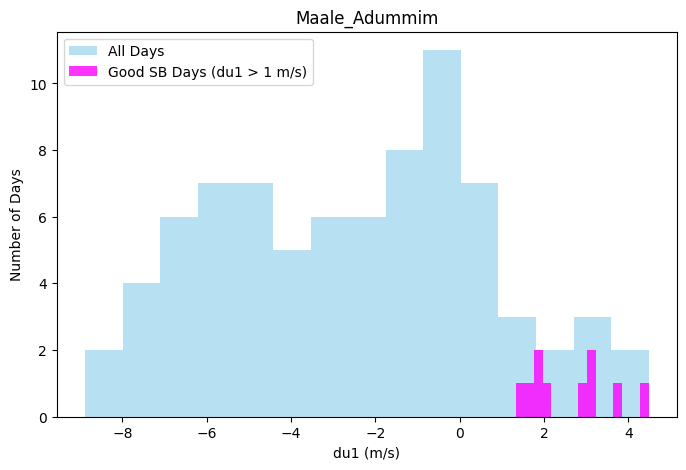

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3 AND dsh
def compute_sbf_trend(file_path, year, month, day):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:
        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # # COMPUTE dsh
    # dsh = np.nan
    # try:
    #     n1 = df.index.get_loc(t1)
    #     if (n1 > 0) and (n1 < len(df)-1):
    #         dsh = (df["q_gkg"].iloc[n1+1] - df["q_gkg"].iloc[n1-1])
    # except:
    #     pass

    du1 = np.nan
    try:
      n1 = df.index.get_loc(t1)
      if (n1 >= 6) and (n1 < len(df)-6):
        du1 = (df["V_onshore"].iloc[n1-6] - df["V_onshore"].iloc[n1+6])
    except:
      pass

    # GOOD SB DAY?
    du1_threshold = 1.0
    good_sb1 = False

    if not np.isnan(du1):
        good_sb1 = du1 > du1_threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "du1": du1, "good_sb1": good_sb1}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
du1_all = {station: [] for station in station_files.keys()}

du1_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []

# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, year, month, day)
        if result is None:
            continue

        du1 = result["du1"]

        if np.isnan(du1):
            continue

        # dsh_all[station].append(dsh)

        # if result["good_sb"]:
        #     dsh_good[station].append(dsh)
        du1_all[station].append(du1)

        if result["good_sb1"]:
          du1_good[station].append(du1)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "du1": du1,
                              "Good_SB1": result["good_sb1"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})

# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_du1_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="du1")
pivot_df.to_excel("du1_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    plt.hist(du1_all[station], bins=15, alpha=0.6, label="All Days", color='skyblue')
    plt.hist(du1_good[station], bins=15, alpha=0.8, label="Good SB Days (du1 > 1 m/s)", color='magenta')

    plt.xlabel("du1 (m/s)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()


# **Wind acceleration transition for shore line meteorological stations (Criteria du3 > 2 m/s)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# FUNCTION TO COMPUTE t1, t2, t3 AND dsh
def compute_sbf_trend(file_path, year, month, day, station_name):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100.0 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE
    def moving_slope(series):
        values = series.values
        slopes = [np.nan]
        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes


    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # Strongest moisture increase
    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:
        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()
    else:
        t2 = pd.NaT

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # WIND JUMP METRIC
    # Other stations -> du1 at t1
    du_metric = np.nan
    try:
      if station_name == "Ashdod":
        n3 = df.index.get_loc(t3)
        if (n3 >= 6) and (n3 < len(df)-6):
          du_metric = (df["V_onshore"].iloc[n3-6] - df["V_onshore"].iloc[n3+6])
        else:
          n1 = df.index.get_loc(t1)
          # ±1 hour around t1
          if (n1 >= 6) and (n1 < len(df)-6):
            du_metric = (df["V_onshore"].iloc[n1+6]- df["V_onshore"].iloc[n1-6])
    except:
      pass

    # GOOD SB DAY?
    good_sb1 = False
    if station_name == "Ashdod":
        threshold = 2.0
    else:
        threshold = 1.0

    if not np.isnan(du_metric):
        good_sb1 = du_metric > threshold

    return {"df": df, "t1": t1, "t2": t2, "t3": t3, "du_metric": du_metric, "good_sb1": good_sb1}


# FILES
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# DATE RANGE & STORAGE
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")
du_metric_all = {station: [] for station in station_files.keys()}

du_metric_good = {
    station: []
    for station in station_files.keys()
}

# Saving the dates
results_table = []

# LOOP THROUGH DAYS
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(file, year, month, day, station)
        if result is None:
            continue

        du_metric = result["du_metric"]

        if np.isnan(du_metric):
            continue

        # dsh_all[station].append(dsh)

        # if result["good_sb"]:
        #     dsh_good[station].append(dsh)
        du_metric_all[station].append(du_metric)

        if result["good_sb1"]:
          du_metric_good[station].append(du_metric)

        # Save day-wise information
        results_table.append({"Date": current_date, "Station": station, "du_metric": du_metric,
                              "Good_SB1": result["good_sb1"],
                              "t1_time": result["t1"].strftime("%H:%M") if pd.notna(result["t1"]) else None})

# SHowing the saved data
results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Daily_du_metric_results.xlsx", index=False)

pivot_df = results_df.pivot(index="Date", columns="Station", values="du_metric")
pivot_df.to_excel("du_metric_by_station.xlsx")


# HISTOGRAMS
for station in station_files.keys():
    plt.figure(figsize=(8,5))
    plt.hist(du1_all[station], bins=15, alpha=0.6, label="All Days", color='skyblue')
    if station == "Ashdod":
      label_txt = "Good SB Days (du3 > 2 m/s)"
    else:
      label_txt = "Good SB Days (du1 > 1 m/s)"
    plt.hist(du1_good[station], bins=15, alpha=0.8, label=label_txt, color='magenta')
    plt.xlabel("du_metric (m/s)")
    plt.ylabel("Number of Days")
    plt.title(f"{station}")
    plt.legend()
    plt.show()

# **Only for shore line station i.e., Ashdod Station**

# **New Practice**

        Date       du3  Good_SB1 t1_time t2_time t3_time
0 2025-06-01  4.014013      True   05:10   05:10   05:40
1 2025-06-02  3.791260      True   14:50   14:50   05:40
2 2025-06-03 -2.054627     False   09:50   09:50   14:50
3 2025-06-04  4.247791      True   05:40   05:40   06:10
4 2025-06-05  3.222144      True   06:20   06:20   06:50


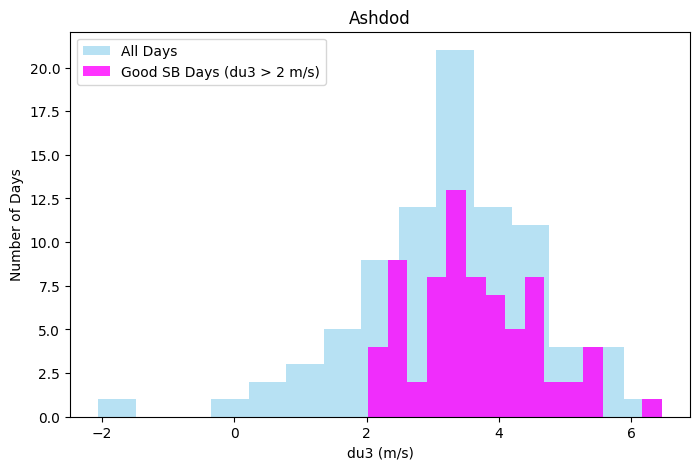

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def compute_sbf_trend(file_path, year, month, day):
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[["Date & Time (UTC)", "Wind speed (m/s)", "Wind direction (°)",
             "Relative humidity (%)", "Temperature (°C)"]].copy()

    df.columns = df.columns.str.strip()
    numeric_cols = ["Wind speed (m/s)", "Wind direction (°)",
                    "Relative humidity (%)", "Temperature (°C)"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # FILTER DAY
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # Onshore direction
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # =====================================================
    # SPECIFIC HUMIDITY
    # =====================================================

    T_K = df["Temperature (°C)"] + 273.15

    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100 / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # =====================================================
    # MOVING SLOPE
    # =====================================================

    def moving_slope(series):

        values = series.values

        slopes = [np.nan]

        x = np.array([0, 1, 2])

        for i in range(1, len(values)-1):

            y = np.array([
                values[i-1],
                values[i],
                values[i+1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes

    # =====================================================
    # COMPUTE SLOPES
    # =====================================================

    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # =====================================================
    # t1, t2, t3
    # =====================================================

    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # t1 = strongest moisture increase

    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:

        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()

    else:

        t2 = pd.NaT

    # t3 = strongest increase in onshore wind

    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # du3 = V_onshore(t3-1h) - V_onshore(t3+1h)
    du3 = np.nan

    try:
        n3 = df.index.get_loc(t3)
        if (n3 >= 6) and (n3 < len(df)-6):
            du3 = -(df["V_onshore"].iloc[n3-6]- df["V_onshore"].iloc[n3+6])
    except:
        pass

    # =====================================================
    # GOOD SEA BREEZE DAY?
    # =====================================================

    good_sb1 = False

    if not np.isnan(du3):
        good_sb1 = du3 > 2.0

    return {
        "df": df,
        "t1": t1,
        "t2": t2,
        "t3": t3,
        "du3": du3,
        "good_sb1": good_sb1
    }



file_path = "/content/Ashdod_data.xlsx"
dates = pd.date_range(start="2025-06-01", periods=92, freq="D")

du3_all = []
du3_good = []

results_table = []


for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    result = compute_sbf_trend(
        file_path,
        year,
        month,
        day
    )

    if result is None:
        continue

    du3 = result["du3"]

    if np.isnan(du3):
        continue

    du3_all.append(du3)
    if result["good_sb1"]:
        du3_good.append(du3)

    results_table.append({
        "Date": current_date,
        "du3": du3,
        "Good_SB1": result["good_sb1"],
        "t1_time":
            result["t1"].strftime("%H:%M")
            if pd.notna(result["t1"])
            else None,
        "t2_time":
            result["t2"].strftime("%H:%M")
            if pd.notna(result["t2"])
            else None,
        "t3_time":
            result["t3"].strftime("%H:%M")
            if pd.notna(result["t3"])
            else None
    })


results_df = pd.DataFrame(results_table)
print(results_df.head())
results_df.to_excel("Ashdod_du3_results.xlsx", index=False)

plt.figure(figsize=(8, 5))
plt.hist(du3_all, bins=15, alpha=0.6, label="All Days", color="skyblue")
plt.hist(du3_good, bins=15, alpha=0.8, label="Good SB Days (du3 > 2 m/s)", color="magenta")
plt.xlabel("du3 (m/s)")
plt.ylabel("Number of Days")
plt.title("Ashdod")
plt.legend()

plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FUNCTION TO COMPUTE t1, t2, t3 AND WIND JUMP METRIC
# ============================================================
def compute_sbf_trend(file_path, year, month, day, station):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # --------------------------------------------------------
    # FILTER DAY
    # --------------------------------------------------------
    df = df[
        (df.index.year == year) &
        (df.index.month == month) &
        (df.index.day == day)
    ].between_time("04:00", "16:00")

    df = df.dropna()

    if len(df) < 3:
        return None

    # --------------------------------------------------------
    # WIND COMPONENTS
    # --------------------------------------------------------
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values

    u = -V * np.sin(theta)
    v = -V * np.cos(theta)

    df["u"] = u
    df["v"] = v

    # --------------------------------------------------------
    # ONSHORE WIND COMPONENT
    # --------------------------------------------------------
    alpha = np.deg2rad(100)

    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # --------------------------------------------------------
    # SPECIFIC HUMIDITY
    # --------------------------------------------------------
    T_K = df["Temperature (°C)"] + 273.15

    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    RH = (df["Relative humidity (%)"]*100) / 100.0

    df["q"] = (
        RH
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000

    # --------------------------------------------------------
    # MOVING SLOPE
    # --------------------------------------------------------
    def moving_slope(series):

        values = series.values

        slopes = [np.nan]

        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([
                values[i - 1],
                values[i],
                values[i + 1]
            ])

            slope, _ = np.polyfit(x, y, 1)

            slopes.append(slope)

        slopes.append(np.nan)

        return slopes

    # --------------------------------------------------------
    # COMPUTE SLOPES
    # --------------------------------------------------------
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    if len(df) < 3:
        return None

    # --------------------------------------------------------
    # t1, t2, t3
    # --------------------------------------------------------
    mask_u_positive = df["V_onshore"] > 0

    if mask_u_positive.sum() == 0:
        return None

    # t1 = strongest moisture increase
    t1 = df.loc[
        mask_u_positive,
        "q_3point_slope"
    ].idxmax()

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        & (df["V_onshore"] > 0)
    )

    if mask_t2.sum() > 0:
        t2 = df.loc[
            mask_t2,
            "q_3point_slope"
        ].idxmax()
    else:
        t2 = pd.NaT

    # t3 = strongest increase in onshore wind
    t3 = df.loc[
        mask_u_positive,
        "Vonshore_3point_slope"
    ].idxmax()

    # --------------------------------------------------------
    # WIND JUMP METRIC
    # --------------------------------------------------------
    du_metric = np.nan

    try:

        if station_name == "Ashdod":

            n3 = df.index.get_loc(t3)

            if (n3 >= 6) and (n3 < len(df) - 6):

                # du3 = u(t3-1h) - u(t3+1h)
                du_metric = (
                    df["V_onshore"].iloc[n3 - 6]
                    - df["V_onshore"].iloc[n3 + 6]
                )

        else:

            n1 = df.index.get_loc(t1)

            if (n1 >= 6) and (n1 < len(df) - 6):

                # du1 = u(t1+1h) - u(t1-1h)
                du_metric = (
                    df["V_onshore"].iloc[n1 + 6]
                    - df["V_onshore"].iloc[n1 - 6]
                )

    except:
      pass
    # --------------------------------------------------------
    # GOOD SB DAY?
    # --------------------------------------------------------
    if station == "Ashdod":
        threshold = 2.0
    else:
        threshold = 1.0

    good_sb1 = False

    if not np.isnan(du_metric):
        good_sb1 = du_metric > threshold

    return {
        "df": df,
        "t1": t1,
        "t2": t2,
        "t3": t3,
        "du_metric": du_metric,
        "good_sb1": good_sb1
    }


# ============================================================
# FILES
# ============================================================
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


# ============================================================
# DATE RANGE
# ============================================================
dates = pd.date_range(
    start="2025-06-01",
    periods=10,
    freq="D"
)

du_metric_all = {
    station: []
    for station in station_files.keys()
}

du_metric_good = {
    station: []
    for station in station_files.keys()
}

results_table = []


# ============================================================
# LOOP THROUGH DAYS
# ============================================================
for current_date in dates:

    year = current_date.year
    month = current_date.month
    day = current_date.day

    for station, file in station_files.items():

        result = compute_sbf_trend(
            file,
            year,
            month,
            day,
            station
        )

        if result is None:
            continue

        du_metric = result["du_metric"]

        if np.isnan(du_metric):
            continue

        du_metric_all[station].append(
            du_metric
        )

        if result["good_sb1"]:
            du_metric_good[station].append(
                du_metric
            )

        results_table.append({
            "Date": current_date,
            "Station": station,
            "du_metric": du_metric,
            "Good_SB1": result["good_sb1"],
            "t1_time":
                result["t1"].strftime("%H:%M")
                if pd.notna(result["t1"])
                else None,
            "t3_time":
                result["t3"].strftime("%H:%M")
                if pd.notna(result["t3"])
                else None
        })


# ============================================================
# SAVE RESULTS
# ============================================================
results_df = pd.DataFrame(results_table)

print(results_df.head())

results_df.to_excel(
    "Daily_du_metric_results.xlsx",
    index=False
)

pivot_df = results_df.pivot(
    index="Date",
    columns="Station",
    values="du_metric"
)

pivot_df.to_excel(
    "du_metric_by_station.xlsx"
)

print("Excel files saved.")


# ============================================================
# HISTOGRAMS
# ============================================================
for station in station_files.keys():

    plt.figure(figsize=(8, 5))

    plt.hist(
        du_metric_all[station],
        bins=15,
        alpha=0.6,
        label="All Days",
        color="skyblue"
    )

    if station == "Ashdod":
        label_txt = "Good SB Days (du3 > 2 m/s)"
    else:
        label_txt = "Good SB Days (du1 > 1 m/s)"

    plt.hist(
        du_metric_good[station],
        bins=15,
        alpha=0.8,
        label=label_txt,
        color="magenta"
    )

    plt.xlabel("du_metric (m/s)")
    plt.ylabel("Number of Days")
    plt.title(station)
    plt.legend()

    plt.show()

ParseError: not well-formed (invalid token): line 2, column 15428519 (<string>)

# **Combination of 5 subplots**

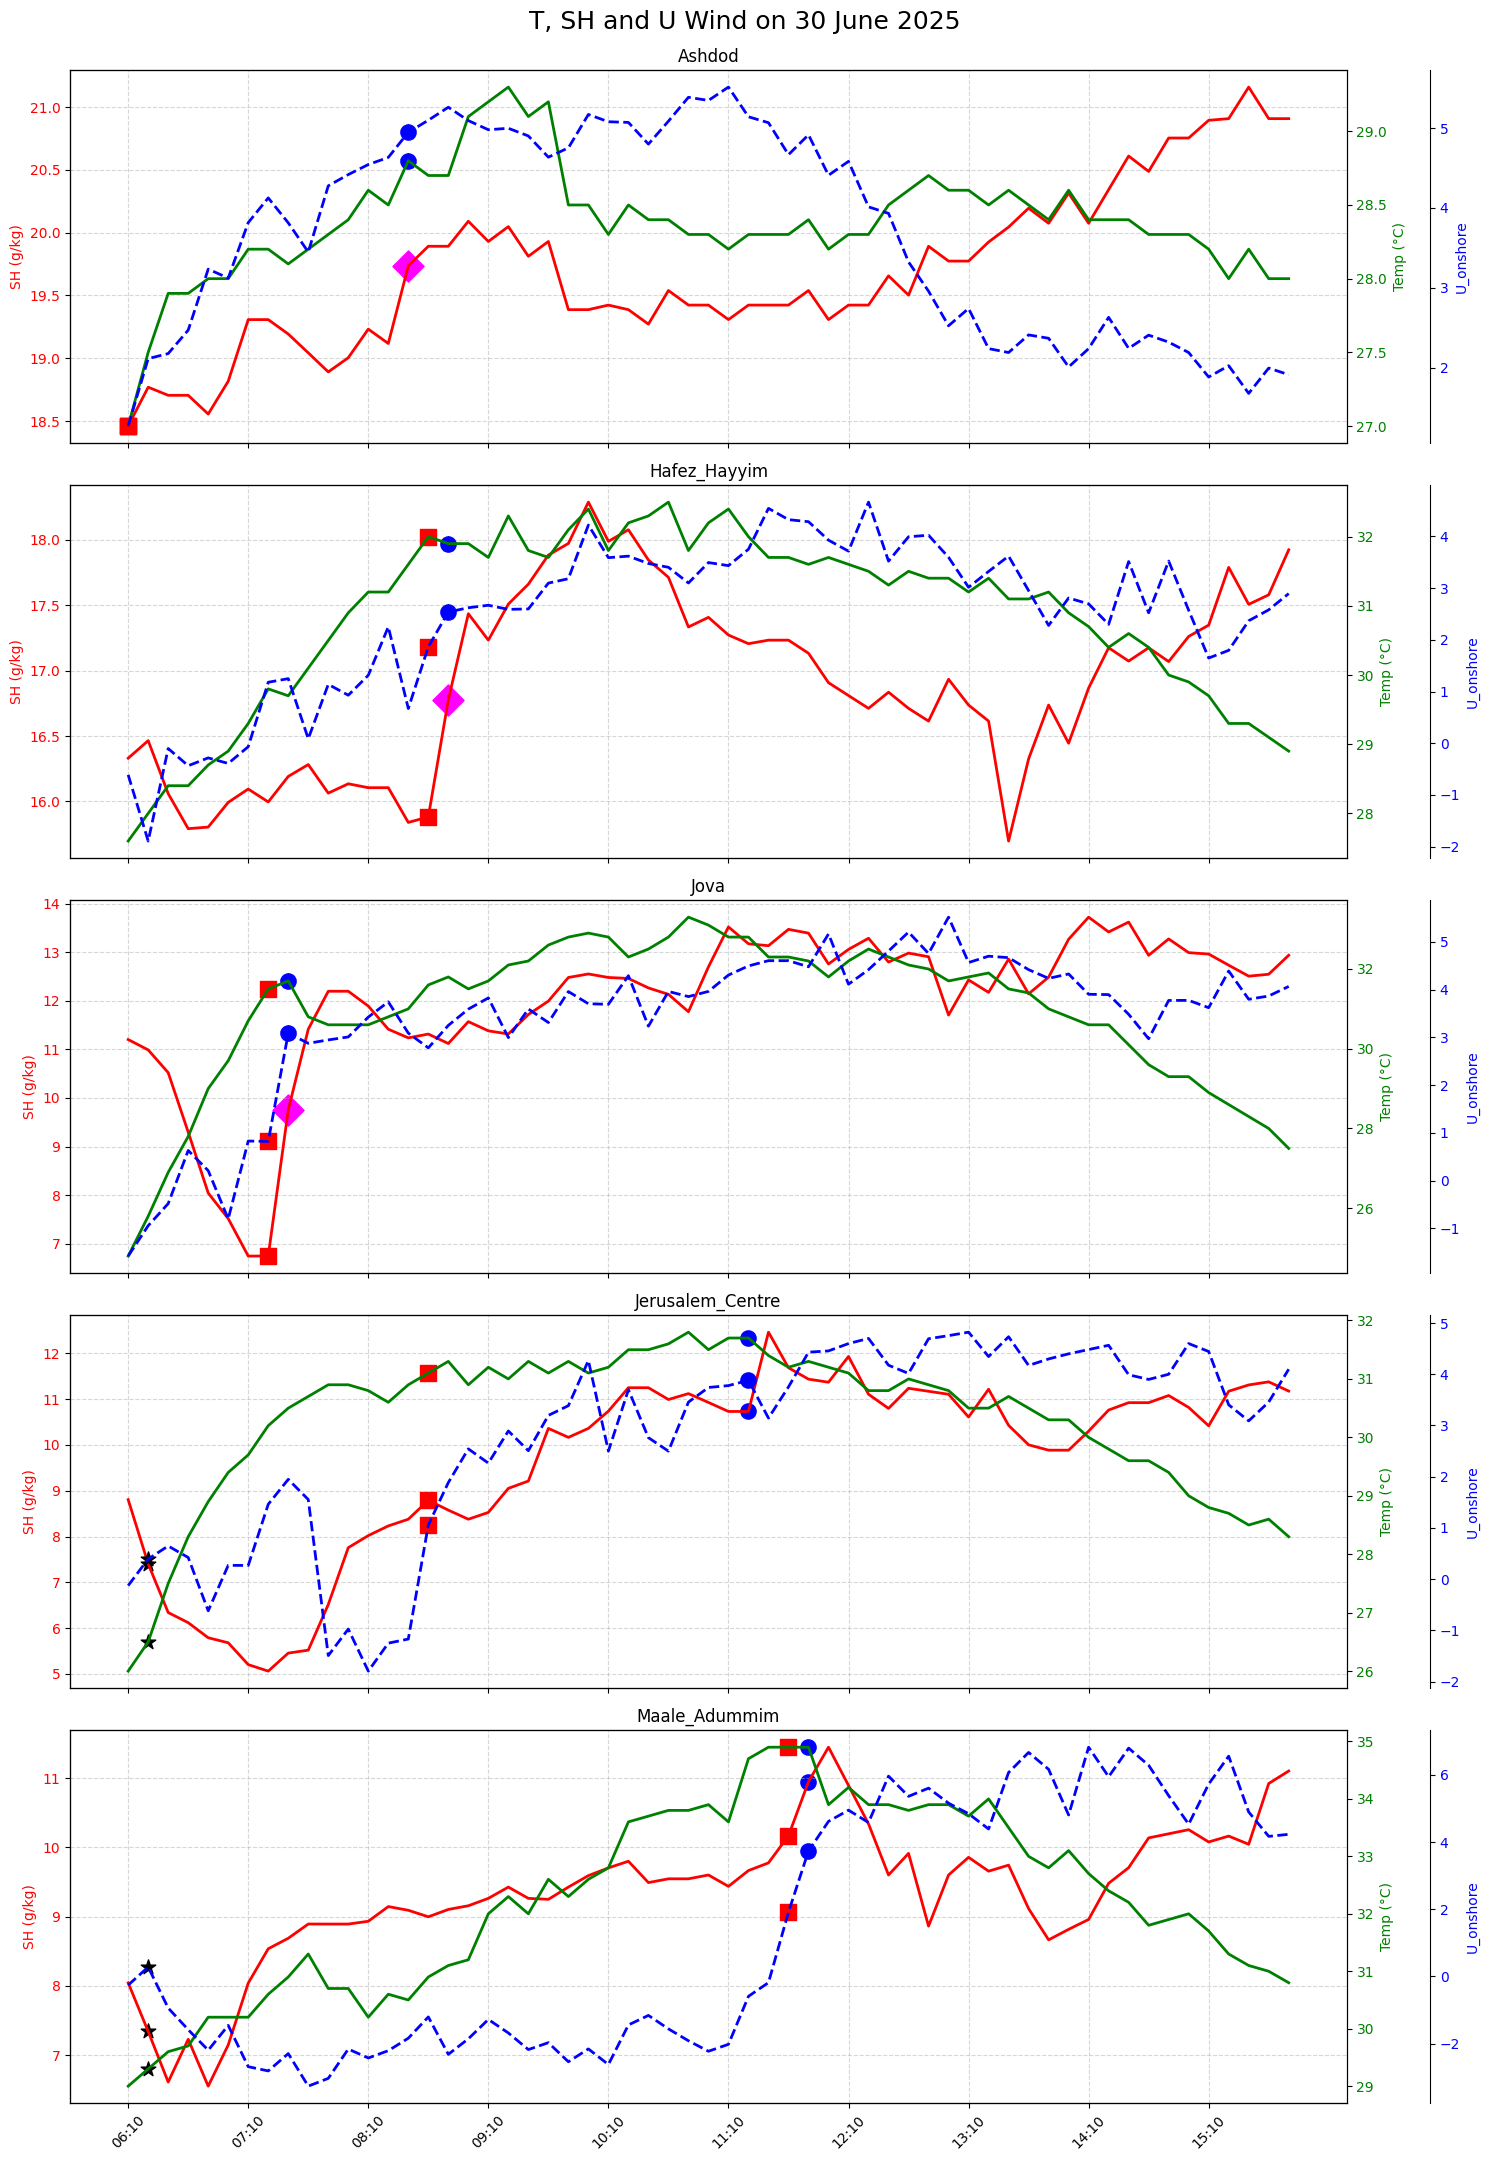

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to compute t1, t2 & t3
def compute_sbf_trend(file_path):

    # Read Excel file
    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    # Remove extra spaces
    df.columns = df.columns.str.strip()
    # Convert numeric columns
    numeric_cols = [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)

    df.set_index("Date & Time (UTC)", inplace=True)

    # Filter date and time
    df = df[
        (df.index.year == 2025) &
        (df.index.month == 6) &
        (df.index.day == 30)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # WIND COMPONENTS
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    alpha = np.deg2rad(100)
    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # SPECIFIC HUMIDITY
    T_K = df["Temperature (°C)"] + 273.15
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"]*100 / 100.0)* (R / Rv)* (A / p)* np.exp(-B / T_K))

    df["q_gkg"] = df["q"] * 1000

    # MOVING SLOPE FUNCTION

    def moving_slope(series):
        values = series.values
        slopes = [np.nan]

        x = np.array([0, 1, 2])

        for i in range(1, len(values) - 1):

            y = np.array([values[i - 1], values[i], values[i + 1]])
            slope, intercept = np.polyfit(x, y, 1)
            slopes.append(slope)
        slopes.append(np.nan)
        return slopes

    # COMPUTE SLOPES
    df["Temp_3point_slope"] = moving_slope(
        df["Temperature (°C)"]
    )

    df["q_3point_slope"] = moving_slope(
        df["q_gkg"]
    )

    df["Vonshore_3point_slope"] = moving_slope(
        df["V_onshore"]
    )

    df = df.dropna()

    # t1, t2, t3
    mask_u_positive = df["V_onshore"] > 0
    t1 = (
        df.loc[mask_u_positive,
               "q_3point_slope"]
        .abs()
        .idxmax()
    )

    mask_t2 = (
        (df["q_3point_slope"] > 0)
        &
        (df["V_onshore"] > 0)
    )

    t2 = (
        df.loc[mask_t2,
               "q_3point_slope"]
        .idxmax()
    )

    t3 = (
        df.loc[mask_u_positive,
               "Vonshore_3point_slope"]
        .idxmax()
    )

    # Store flags
    df["t1"] = False
    df["t2"] = False
    df["t3"] = False

    df.loc[t1, "t1"] = True
    df.loc[t2, "t2"] = True
    df.loc[t3, "t3"] = True

    return df


# FILES FOR 5 STATIONS
station_files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Tzuba": "/content/Tzuba_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

# COMPUTE RESULTS
results = {}
for station, file in station_files.items():
    results[station] = compute_sbf_trend(file)

# PLOT ALL 5 STATIONS
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(15, 22),
    sharex=True
)

for ax, (station, df) in zip(axes, results.items()):

    # Axis 1 → Specific Humidity
    ax.plot(
        df.index,
        df["q_gkg"],
        color="red",
        linewidth=2,
        label="Specific Humidity"
    )

    ax.set_ylabel(
        "SH (g/kg)",
        color="red"
    )

    ax.tick_params(
        axis='y',
        labelcolor="red"
    )

     # Axis 2 → Temperature
    ax2 = ax.twinx()
    ax2.plot(
        df.index,
        df["Temperature (°C)"],
        color="green",
        linewidth=2,
        label="Temperature"
    )

    ax2.set_ylabel(
        "Temp (°C)",
        color="green"
    )

    ax2.tick_params(
        axis='y',
        labelcolor="green"
    )

    # Axis 3 → Onshore Wind
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(
        ("outward", 60)
    )

    ax3.plot(
        df.index,
        df["V_onshore"],
        color="blue",
        linestyle="--",
        linewidth=2,
        label="Onshore Wind"
    )

    ax3.set_ylabel(
        "U_onshore",
        color="blue"
    )

    ax3.tick_params(
        axis='y',
        labelcolor="blue"
    )

    # t1 markers

    t1_row = df[df["t1"]]
    ax.scatter(
        t1_row.index,
        t1_row["q_gkg"],
        marker="*",
        s=120,
        color="black"
    )

    ax2.scatter(
        t1_row.index,
        t1_row["Temperature (°C)"],
        marker="*",
        s=120,
        color="black"
    )

    ax3.scatter(
        t1_row.index,
        t1_row["V_onshore"],
        marker="*",
        s=120,
        color="black"
    )

    # t2 markers
    t2_row = df[df["t2"]]
    ax.scatter(
        t2_row.index,
        t2_row["q_gkg"],
        marker="o",
        s=120,
        color="blue"
    )

    ax2.scatter(
        t2_row.index,
        t2_row["Temperature (°C)"],
        marker="o",
        s=120,
        color="blue"
    )

    ax3.scatter(
        t2_row.index,
        t2_row["V_onshore"],
        marker="o",
        s=120,
        color="blue"
    )

    # t3 markers
    t3_row = df[df["t3"]]
    ax.scatter(
        t3_row.index,
        t3_row["q_gkg"],
        marker="s",
        s=120,
        color="red"
    )

    ax2.scatter(
        t3_row.index,
        t3_row["Temperature (°C)"],
        marker="s",
        s=120,
        color="red"
    )

    ax3.scatter(
        t3_row.index,
        t3_row["V_onshore"],
        marker="s",
        s=120,
        color="red"
    )


    # Overlap points
    df["overlap_count"] = (df[["t1", "t2", "t3"]].sum(axis=1))

    overlap = df[df["overlap_count"] > 1]
    overlap_scatter = ax.scatter(
    overlap.index,
    overlap["q_gkg"],
    marker="D",
    color="magenta",
    s=250,
    label="Overlap")



    # Formatting
    ax.set_title(station)

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    ax.set_xticks(df.index[::6])

    ax.set_xticklabels(
        df.index[::6].strftime("%H:%M"),
        rotation=45
    )

# FIGURE TITLE
fig.suptitle(
    "T, SH and U Wind on 30 June 2025\n", fontsize=18)

plt.tight_layout()

plt.savefig(
    "All_Stations_SBF.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# **Finding the 3-point moving trend for V_onshore, Specific Humidity and Temperature Gradient.**

In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_trend(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()
    df.columns = df.columns.str.strip()

    # Convert numeric columns
    for col in [
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # Datetime handling
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )

    df.set_index("Date & Time (UTC)", inplace=True)

    # Filter data
    df = df[
        (df.index.year == 2024) &
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "16:00")

    df = df.dropna()

    # Onshore wind component
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    # Wind components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    # Coastline orientation angle
    alpha = np.deg2rad(100)
    df["V_onshore"] = (
        df["u"] * np.sin(alpha)
        + df["v"] * np.cos(alpha)
    )

    # Specific humidity
    T_K = df["Temperature (°C)"] + 273.15
    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (
        (df["Relative humidity (%)"] / 100.0)
        * (R / Rv)
        * (A / p)
        * np.exp(-B / T_K)
    )

    df["q_gkg"] = df["q"] * 1000  # g/kg


    # 3-point slope function
    def slope_3pt(y):
        # Time axis in minutes
        x = np.array([0, 10, 20])
        # Linear regression slope
        m = np.polyfit(x, y, 1)[0]

        return m

    # 3-point moving trend slopes
    # Temperature trend
    df["dT_s"] = (
        df["Temperature (°C)"]
        .rolling(window=3, center=True)
        .apply(slope_3pt, raw=True)
    )

    # Specific humidity trend
    df["dq_s"] = (
        df["q_gkg"]
        .rolling(window=3, center=True)
        .apply(slope_3pt, raw=True)
    )

    # Onshore wind trend
    df["V_s"] = (
        df["V_onshore"]
        .rolling(window=3, center=True)
        .apply(slope_3pt, raw=True)
    )

    #df = df.dropna()

    return df

#file_path = "/content/Jova_data.xlsx"
file_path = "/content/Jerusalem_Centre_data.xlsx"

df_result = compute_sbf_trend(file_path)

# **Checking on 17th June data and indicators**

In [ ]:
import pandas as pd
import numpy as np

# Read Excel file
df = pd.read_excel("/content/Jerusalem_Centre_data.xlsx", engine="openpyxl")
df = df[[
    "Date & Time (UTC)",
    "Wind speed (m/s)",
    "Wind direction (°)",
    "Relative humidity (%)",
    "Temperature (°C)"
    ]].copy()

# Remove extra spaces & Convert numeric columns
df.columns = df.columns.str.strip()
numeric_cols = [
    "Wind speed (m/s)",
    "Wind direction (°)",
    "Relative humidity (%)",
    "Temperature (°C)"
    ]

for col in numeric_cols:
  df[col] = pd.to_numeric(df[col], errors="coerce")

# Datetime handling
df["Date & Time (UTC)"] = pd.to_datetime(
    df["Date & Time (UTC)"], dayfirst=True)

df.set_index("Date & Time (UTC)", inplace=True)

# Filter required date and time
df = df[
    (df.index.year == 2025) &
    (df.index.month == 5) &
    (df.index.day == 17)
    ].between_time("06:00", "16:00")

In [ ]:
# WIND COMPONENTS
theta = np.deg2rad(df["Wind direction (°)"].values)
V = df["Wind speed (m/s)"].values
u = -V * np.sin(theta)
v = -V * np.cos(theta)
df["u"] = u
df["v"] = v
alpha = np.deg2rad(100)
df["V_onshore"] = (df["u"] * np.sin(alpha) + df["v"] * np.cos(alpha))

# SPECIFIC HUMIDITY
T_K = df["Temperature (°C)"] + 273.15
A = 2.53e7
B = 5420
R = 287
Rv = 461
p = 920

df["q"] = ((df["Relative humidity (%)"]*100 / 100.0)* (R / Rv)* (A / p)* np.exp(-B / T_K))
df["q_gkg"] = df["q"] * 1000

# MOVING SLOPE FUNCTION
def moving_slope(series):
    values = series.values
    slopes = [np.nan]
    x = np.array([0, 1, 2])
    for i in range(1, len(values) - 1):
        y = np.array([
            values[i - 1],
            values[i],
            values[i + 1]
        ])
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
    slopes.append(np.nan)
    return slopes

# COMPUTE SLOPES
df["Temp_3point_slope"] = moving_slope(df["Temperature (°C)"])
df["q_3point_slope"] = moving_slope(df["q_gkg"])
df["Vonshore_3point_slope"] = moving_slope(df["V_onshore"])
df = df.dropna()

# t1, t2, t3
mask_u_positive = df["V_onshore"] > 0
t1 = (df.loc[mask_u_positive,"q_3point_slope"].abs().idxmax())

mask_t2 = ((df["q_3point_slope"] > 0) & (df["V_onshore"] > 0))

#t2 = (df.loc[mask_t2, "q_3point_slope"].idxmax())

mask_t2 = (
    (df["q_3point_slope"] > 0)
    &
    (df["V_onshore"] > 0)
)

if mask_t2.any():

    t2 = df.loc[
        mask_t2,
        "q_3point_slope"
    ].idxmax()

else:

    t2 = t1

t3 = (df.loc[mask_u_positive, "Vonshore_3point_slope"].idxmax())

# Store flags
df["t1"] = False
df["t2"] = False
df["t3"] = False

df.loc[t1, "t1"] = True
df.loc[t2, "t2"] = True
df.loc[t3, "t3"] = True

/tmp/ipykernel_6039/3111884905.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["t1"] = False
/tmp/ipykernel_6039/3111884905.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["t2"] = False
/tmp/ipykernel_6039/3111884905.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

In [ ]:
#print(df.head())
print(df["t2"].value_counts())
#print(t3)

t2
False    44
True      1
Name: count, dtype: int64


# **Working on the code**

In [ ]:
#print(result.head())

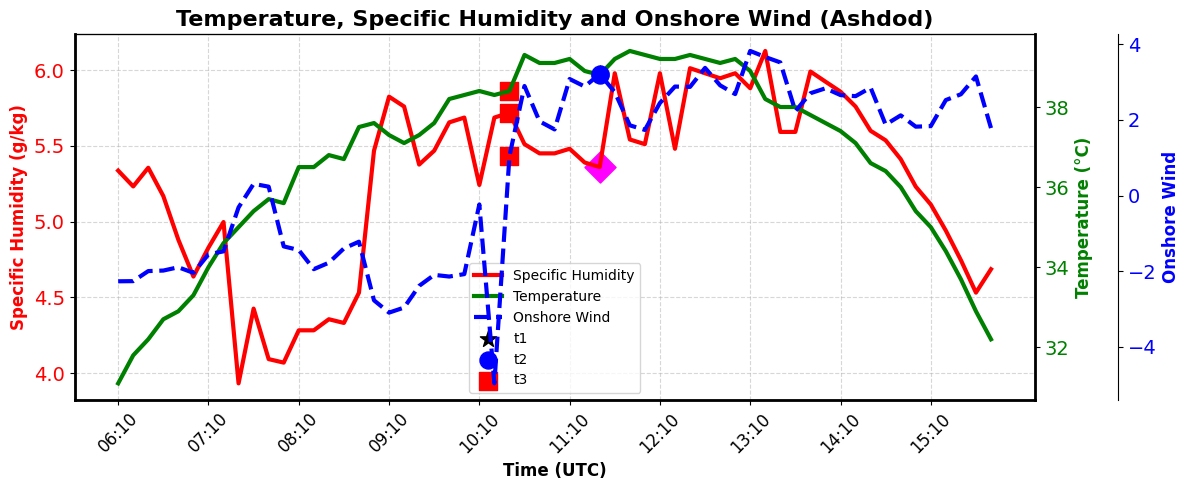

In [ ]:
import matplotlib.pyplot as plt


def plot_combined_sbf_slopes(df):

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Specific humidity
    ax1.plot(
        df.index,
        df["q_gkg"],
        color="red",
        linewidth=3,
        label="Specific Humidity")

    ax1.set_ylabel("Specific Humidity (g/kg)", color="red", fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor="red", labelsize=14)

    # Temperature axis
    ax2 = ax1.twinx()

    ax2.plot(
        df.index,
        df["Temperature (°C)"],
        color="green",
        linewidth=3,
        label="Temperature")

    ax2.set_ylabel("Temperature (°C)", color="green", fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor="green", labelsize=14)


    # Onshore wind axis
    ax3 = ax1.twinx()

    # Move third axis outward
    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        df.index,
        df["V_onshore"],
        color="blue",
        linestyle="--",
        linewidth=3,
        label="Onshore Wind")

    ax3.set_ylabel("Onshore Wind", color="blue", fontsize=12, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor="blue", labelsize=14)

    # t1 points
    t1_row = df[df["t1"]]

    t1_scatter = ax1.scatter(
        t1_row.index,
        t1_row["q_gkg"],
        marker="*",
        color="black",
        s=150,
        label="t1"
    )

    ax2.scatter(
        t1_row.index,
        t1_row["Temperature (°C)"],
        marker="*",
        color="black",
        s=150
    )

    ax3.scatter(
        t1_row.index,
        t1_row["V_onshore"],
        marker="*",
        color="black",
        s=150
    )

    # t2 points
    t2_row = df[df["t2"]]

    t2_scatter = ax1.scatter(
        t2_row.index,
        t2_row["q_gkg"],
        marker="o",
        color="blue",
        s=150,
        label="t2"
    )

    ax2.scatter(
        t2_row.index,
        t2_row["Temperature (°C)"],
        marker="o",
        color="blue",
        s=150
    )

    ax3.scatter(
        t2_row.index,
        t2_row["V_onshore"],
        marker="o",
        color="blue",
        s=150
    )

    # t3 points
    t3_row = df[df["t3"]]

    t3_scatter = ax1.scatter(
        t3_row.index,
        t3_row["q_gkg"],
        marker="s",
        color="red",
        s=150,
        label="t3"
    )

    ax2.scatter(
        t3_row.index,
        t3_row["Temperature (°C)"],
        marker="s",
        color="red",
        s=150
    )

    ax3.scatter(
        t3_row.index,
        t3_row["V_onshore"],
        marker="s",
        color="red",
        s=150
    )


    # Overlap points
    df["overlap_count"] = (
        df[["t1", "t2", "t3"]].sum(axis=1))

    overlap = df[df["overlap_count"] > 1]
    overlap_scatter = ax1.scatter(
    overlap.index,
    overlap["q_gkg"],
    marker="D",
    color="magenta",
    s=250,
    label="Overlap")

    # X-axis formatting
    ax1.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
    ax1.set_xticks(df.index[::6])
    ax1.set_xticklabels(df.index[::6].strftime("%H:%M"),
                        rotation=45, fontsize= 12)

    # Title
    plt.title("Temperature, Specific Humidity and Onshore Wind (Ashdod)",
              fontsize=16, fontweight='bold')

    # Combined legend
    lines = (
        ax1.get_lines()
        + ax2.get_lines()
        + ax3.get_lines()
    )

    labels = [l.get_label() for l in lines]

    # Add scatter handles
    lines.extend([
        t1_scatter,
        t2_scatter,
        t3_scatter
    ])

    labels.extend([
        "t1",
        "t2",
        "t3"
    ])

    ax1.legend(
        lines,
        labels,
        loc="best"
    )

    # Grid
    ax1.grid(
        True,
        linestyle="--",
        alpha=0.5
    )


    ax1.spines["bottom"].set_linewidth(2)
    ax1.spines["left"].set_linewidth(2)
    ax1.spines["right"].set_linewidth(2)
    #ax3.spines["left"].set_linewidth(3)

    # Layout and save
    plt.tight_layout()

    plt.savefig(
        "SBF_3point_trends.jpg",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# Call function
plot_combined_sbf_slopes(result)

In [ ]:
#print(result.head(5))
print(result.isnull().sum(axis=0))

Wind speed (m/s)         0
Wind direction (°)       0
Relative humidity (%)    0
Temperature (°C)         0
u                        0
v                        0
V_onshore                0
q                        0
q_gkg                    0
Temp_3point_slope        2
q_3point_slope           2
Vonshore_3point_slope    2
dtype: int64


In [ ]:
print(df_result.head())

Empty DataFrame
Columns: [Wind speed (m/s), Wind direction (°), Relative humidity (%), Temperature (°C), dT, u, v, V_onshore, q, q_gkg, dq, dT_n, dq_n, V_n, SBF_index, SBF_flag, SBF_peak]
Index: []


In [ ]:
#print(df_result.head())